# 01 — Discovery y perfilado de datos

Exploración inicial de las **18 tablas** en la capa Bronze (Parquet). Objetivos:

- Volúmenes por dominio y tabla
- Validación de conteos vs. `manifest.json`
- Tipos inferidos y cardinalidades de llaves
- Distribuciones de negocio (estados, segmentos, países)
- Relaciones cruzadas entre dominios (University ↔ Billing ↔ CRM)

## Configuración

In [16]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def get_project_root():
    """Raíz del repo: local (notebooks/) o contenedor Jupyter (/home/jovyan/work)."""
    for path in [Path("/home/jovyan/work"), Path("..").resolve(), Path.cwd()]:
        if (path / "data" / "parquet" / "bronze").exists():
            return path
    raise FileNotFoundError(
        "No se encontró data/parquet/bronze. "
        "Ejecuta desde notebooks/ o levanta Docker Compose."
    )


PROJECT_ROOT = get_project_root()
BRONZE_PATH = PROJECT_ROOT / "data" / "parquet" / "bronze"
MANIFEST_PATH = PROJECT_ROOT / "manifest.json"

with open(MANIFEST_PATH, encoding="utf-8") as f:
    manifest = json.load(f)

DOMAINS = ["university", "billing", "crm"]
sns.set_theme(style="whitegrid")
pd.set_option("display.max_rows", 50)
pd.set_option("display.float_format", "{:.2f}".format)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"Bronze tables: {len(list(BRONZE_PATH.glob('*/*.parquet')))}")

PROJECT_ROOT: /home/jovyan/work
Bronze tables: 18


In [17]:
def load_bronze(domain, table):
    path = BRONZE_PATH / domain / f"{table}.parquet"
    return pd.read_parquet(path)


def list_tables():
    tables = []
    for domain in DOMAINS:
        for table in manifest["domains"][domain]:
            tables.append((domain, table))
    return tables


tables = list_tables()
print(f"Tablas a analizar: {len(tables)}")

Tablas a analizar: 18


## 1. Volúmenes por dominio y tabla

In [20]:
rows_summary = []
for domain, table in tables:
    df = load_bronze(domain, table)
    expected = manifest['domains'][domain][table]['rows']
    actual = len(df)
    rows_summary.append({
        'dominio': domain,
        'tabla': table,
        'filas_bronze': actual,
        'filas_manifest': expected,
        'coincide': actual == expected,
        'columnas_negocio': len(manifest['domains'][domain][table]['cols']),
    })

summary_df = pd.DataFrame(rows_summary)
summary_df

,dominio,tabla,filas_bronze,filas_manifest,coincide,columnas_negocio
0,university,semesters,8,8,True,6
1,university,professors,200,200,True,6
2,university,students,5000,5000,True,7
3,university,courses,300,300,True,6
4,university,enrollments,25000,25000,True,6
5,university,grades,60000,60000,True,6
6,billing,customers,10000,10000,True,8
7,billing,products,200,200,True,6
8,billing,subscriptions,15000,15000,True,6
9,billing,invoices,50000,50000,True,7


# Conteo de filas 

In [21]:
domain_totals = summary_df.groupby('dominio')['filas_bronze'].sum()
print('Total filas por dominio:')
print(domain_totals.to_string())
print(f"\nTotal general: {summary_df['filas_bronze'].sum():,} filas")
print(f"Validación manifest: {summary_df['coincide'].all()}")

Total filas por dominio:
dominio
billing       305200
crm            51000
university     90508

Total general: 446,708 filas
Validación manifest: True


# Comparativa de volumen entre tablas

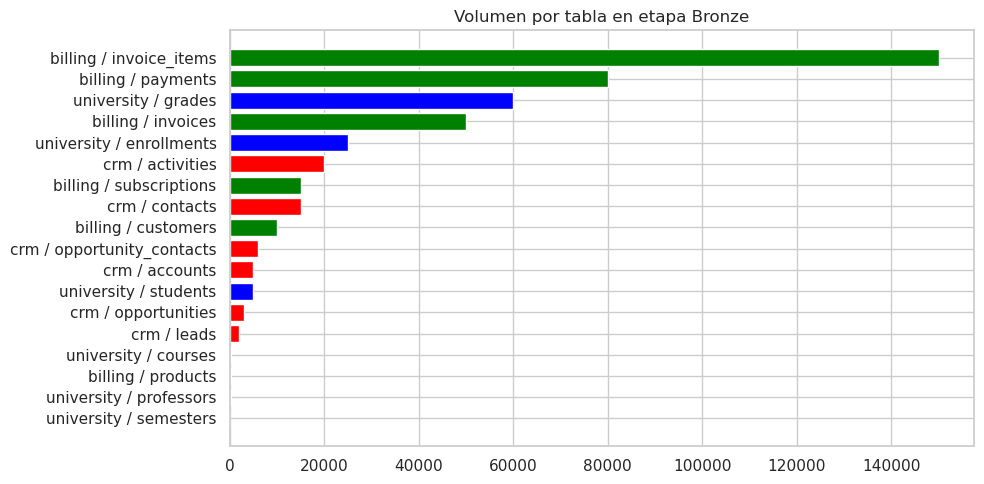

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = summary_df.sort_values('filas_bronze', ascending=True)
labels = plot_df['dominio'] + ' / ' + plot_df['tabla']
ax.barh(labels, plot_df['filas_bronze'])
colors = {'university': '#0000FF', 'billing': '#008000', 'crm': '#FF0000'}
bar_colors = [colors[d] for d in plot_df['dominio']]
ax.clear()
ax.barh(labels, plot_df['filas_bronze'], color=bar_colors)
ax.set_title('Volumen por tabla en etapa Bronze')
plt.tight_layout()
plt.show()

## 2. Esquema y tipos inferidos

In [22]:
schema_rows = []
for domain, table in tables:
    df = load_bronze(domain, table)
    business_cols = manifest['domains'][domain][table]['cols']
    for col in business_cols:
        schema_rows.append({
            'dominio': domain,
            'tabla': table,
            'columna': col,
            'dtype (pandas)': str(df[col].dtype),
            'nulos': df[col].isna().sum(),
            'unicos': df[col].nunique(),
        })

schema_df = pd.DataFrame(schema_rows)
schema_df.head(10)

,dominio,tabla,columna,dtype (pandas),nulos,unicos
0,university,semesters,semester_id,object,0,8
1,university,semesters,code,object,0,8
2,university,semesters,year,int64,0,4
3,university,semesters,half,int64,0,2
4,university,semesters,start_date,object,0,8
5,university,semesters,end_date,object,0,8
6,university,professors,professor_id,object,0,200
7,university,professors,first_name,object,0,50
8,university,professors,last_name,object,0,49
9,university,professors,email,object,0,200


# Columnas de fechas

In [23]:
date_cols = schema_df[schema_df['columna'].str.contains('date|_at', case=False, regex=True)]
date_cols[['dominio', 'tabla', 'columna', 'dtype (pandas)']].drop_duplicates()

,dominio,tabla,columna,dtype (pandas)
4,university,semesters,start_date,object
5,university,semesters,end_date,object
11,university,professors,hired_at,object
16,university,students,birth_date,object
17,university,students,enrolled_at,object
26,university,enrollments,enrolled_at,object
35,university,grades,graded_at,object
43,billing,customers,created_at,object
53,billing,subscriptions,start_date,object
54,billing,subscriptions,end_date,object


# Verificacion de metadatos de bronze

In [8]:
meta_sample = load_bronze('university', 'students')
meta_cols = [c for c in meta_sample.columns if c.startswith('_')]
print('Columnas de metadatos Bronze:', meta_cols)
meta_sample[meta_cols].head(3)

Columnas de metadatos Bronze: ['_ingested_at', '_source_file', '_source_domain']


,_ingested_at,_source_file,_source_domain
0,2026-07-17 03:09:58.239198+00:00,students.csv,university
1,2026-07-17 03:09:58.239198+00:00,students.csv,university
2,2026-07-17 03:09:58.239198+00:00,students.csv,university


## 3. Cardinalidades de llaves primarias

# Verificacion de llaves duplicadas

In [9]:
PK_MAP = {
    'university/semesters': 'semester_id',
    'university/professors': 'professor_id',
    'university/students': 'student_id',
    'university/courses': 'course_id',
    'university/enrollments': 'enrollment_id',
    'university/grades': 'grade_id',
    'billing/customers': 'customer_id',
    'billing/products': 'product_id',
    'billing/subscriptions': 'subscription_id',
    'billing/invoices': 'invoice_id',
    'billing/invoice_items': 'invoice_item_id',
    'billing/payments': 'payment_id',
    'crm/accounts': 'account_id',
    'crm/contacts': 'contact_id',
    'crm/leads': 'lead_id',
    'crm/opportunities': 'opportunity_id',
    'crm/activities': 'activity_id',
}

card_rows = []
for key, pk in PK_MAP.items():
    domain, table = key.split('/')
    df = load_bronze(domain, table)
    card_rows.append({
        'tabla': key,
        'pk': pk,
        'filas': len(df),
        'unicos': df[pk].nunique(),
        'duplicados_pk': df[pk].duplicated().sum(),
    })

card_df = pd.DataFrame(card_rows)
card_df

,tabla,pk,filas,unicos,duplicados_pk
0,university/semesters,semester_id,8,8,0
1,university/professors,professor_id,200,200,0
2,university/students,student_id,5000,5000,0
3,university/courses,course_id,300,300,0
4,university/enrollments,enrollment_id,25000,25000,0
5,university/grades,grade_id,60000,60000,0
6,billing/customers,customer_id,10000,10000,0
7,billing/products,product_id,200,200,0
8,billing/subscriptions,subscription_id,15000,15000,0
9,billing/invoices,invoice_id,50000,50000,0


## 4. Distribuciones de valores de negocio
Tomando como valores de negocio iniciales:
- university / enrollments
- billing / invoices
- billing / customers

In [24]:
enrollments = load_bronze('university', 'enrollments')
invoices = load_bronze('billing', 'invoices')
customers = load_bronze('billing', 'customers')

print('Estado de inscripciones:')
print(enrollments['status'].value_counts())
print('\nEstado de facturas:')
print(invoices['status'].value_counts())
print('\nSegmento de clientes:')
print(customers['segment'].value_counts())

Estado de inscripciones:
status
completed    14931
active        5035
failed        2531
dropped       2503
Name: count, dtype: int64

Estado de facturas:
status
paid       34966
pending    10048
overdue     4986
Name: count, dtype: int64

Segmento de clientes:
segment
retail        7019
smb           2200
enterprise     781
Name: count, dtype: int64


# Definicion de distribucion de valores

Estado de inscripcion

| Categoría | Cantidad | Definición |
|---|---|---|
| **completed** | 14,931 | El estudiante finalizó exitosamente el curso o programa en el que se inscribió (aprobó y cumplió todos los requisitos). |
| **active** | 5,035 | La inscripción está actualmente en curso; el estudiante sigue cursando y no ha llegado a un estado final. |
| **failed** | 2,531 | El estudiante completó el proceso académico pero no cumplió los requisitos mínimos para aprobar (reprobó). |
| **dropped** | 2,503 | El estudiante abandonó o se retiró de la inscripción antes de finalizarla, ya sea de forma voluntaria o por baja administrati

Estado de facturas

| Categoría | Cantidad | Definición |
|---|---|---|
| **paid** | 34,966 | La factura fue pagada en su totalidad; no existe saldo pendiente. |
| **pending** | 10,048 | La factura fue emitida y aún se encuentra dentro del plazo de pago, sin haber vencido todavía. |
| **overdue** | 4,986 | La factura no fue pagada dentro del plazo establecido; el pago está vencid

Segmento de clientes

| Categoría | Cantidad | Definición |
|---|---|---|
| **retail** | 7,019 | Clientes individuales o particulares (estudiantes que pagan/inscriben de forma personal, sin representar a una organización). |
| **smb** | 2,200 | *Small and Medium Business* — clientes institucionales de tamaño pequeño o mediano. |
| **enterprise** | 781 | Clientes corporativos grandes o institucionales de gran escala (convenios con grandes empresas u organizaciones). |o. |va. |

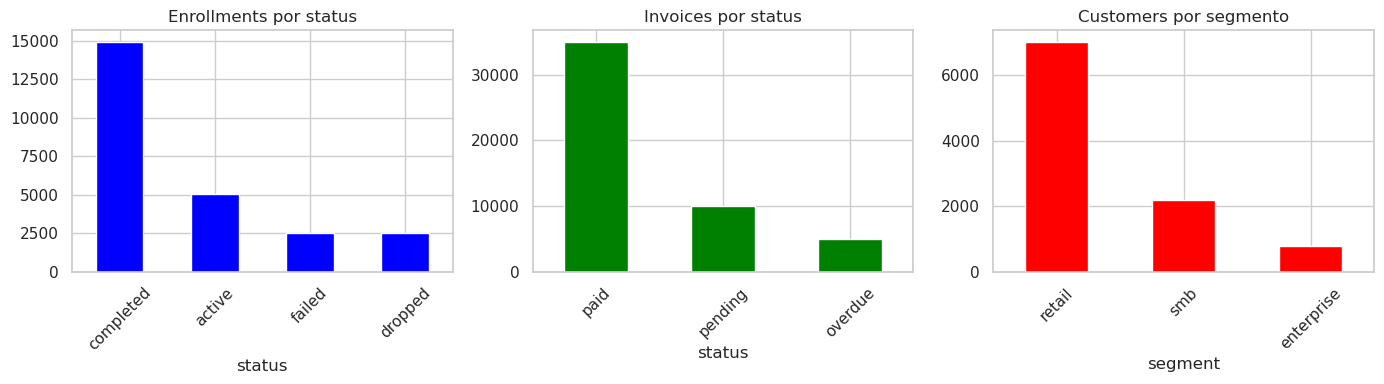

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

enrollments['status'].value_counts().plot(kind='bar', ax=axes[0], color='#0000FF')
axes[0].set_title('Enrollments por status')
axes[0].tick_params(axis='x', rotation=45)

invoices['status'].value_counts().plot(kind='bar', ax=axes[1], color='#008000')
axes[1].set_title('Invoices por status')
axes[1].tick_params(axis='x', rotation=45)

customers['segment'].value_counts().plot(kind='bar', ax=axes[2], color='#FF0000')
axes[2].set_title('Customers por segmento')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [12]:
print('Países — students (top 8):')
print(students['country'].value_counts())
print('\nPaíses — customers (top 8):')
print(customers['country'].value_counts())

accounts = load_bronze('crm', 'accounts')
print('\nPaíses — accounts (top 8):')
print(accounts['country'].value_counts())

Países — students (top 8):
country
CL    1980
AR     523
PE     513
MX     483
BR     427
ES     390
CO     389
US     295
Name: count, dtype: int64

Países — customers (top 8):
country
CL    4053
PE     991
AR     989
MX     969
BR     817
ES     790
CO     775
US     616
Name: count, dtype: int64

Países — accounts (top 8):
country
CL    1499
MX     618
AR     601
PE     512
CO     487
BR     468
ES     428
US     387
Name: count, dtype: int64


In [13]:
subscriptions = load_bronze('billing', 'subscriptions')
leads = load_bronze('crm', 'leads')
activities = load_bronze('crm', 'activities')

print('Suscripciones por status:', subscriptions['status'].value_counts().to_dict())
print('Leads por status:', leads['status'].value_counts().to_dict())
print('Actividades por tipo:', activities['type'].value_counts().to_dict())
print('Métodos de pago:', load_bronze('billing', 'payments')['method'].value_counts().to_dict())

Suscripciones por status: {'active': 11272, 'cancelled': 2242, 'paused': 1486}
Leads por status: {'new': 594, 'contacted': 525, 'qualified': 395, 'lost': 281, 'converted': 205}
Actividades por tipo: {'email': 6904, 'call': 6093, 'meeting': 3016, 'note': 2028, 'demo': 1959}
Métodos de pago: {'card': 43990, 'bank_transfer': 24054, 'paypal': 7987, 'cash': 3969}


# Definicion de distribucion de valores

Suscripciones por status

| Categoría | Cantidad | Definición |
|---|---|---|
| **active** | 11,272 | La suscripción está vigente y en funcionamiento; el cliente tiene acceso al servicio y su facturación continúa de forma normal. |
| **cancelled** | 2,242 | La suscripción fue cancelada por el cliente o por la empresa; el servicio ya no se presta y no se generarán nuevos cobros. |
| **paused** | 1,486 | La suscripción está temporalmente suspendida; el cliente no tiene acceso activo al servicio pero la suscripción no ha sido cancelada definitivamente y puede reactivars

Leads por status

| Categoría | Cantidad | Definición |
|---|---|---|
| **new** | 594 | El lead acaba de ingresar al sistema y aún no ha sido contactado ni gestionado por el equipo de ventas. |
| **contacted** | 525 | Se estableció un primer contacto con el lead (llamada, correo, etc.), pero aún no se ha confirmado su interés o viabilidad. |
| **qualified** | 395 | El lead fue evaluado y cumple con los criterios necesarios para considerarse una oportunidad de venta válida. |
| **lost** | 281 | El lead no avanzó en el proceso comercial; se perdió el interés, la oportunidad o el contacto sin concretar una venta. |
| **converted** | 205 | El lead se transformó exitosamente en cliente, completando el proceso de ve

Actividades por tipo

| Categoría | Cantidad | Definición |
|---|---|---|
| **email** | 6,904 | Actividad registrada que corresponde al envío o recepción de un correo electrónico con el cliente o lead. |
| **call** | 6,093 | Actividad registrada que corresponde a una llamada telefónica realizada o recibida. |
| **meeting** | 3,016 | Actividad registrada que corresponde a una reunión (presencial o virtual) con el cliente o lead. |
| **note** | 2,028 | Actividad registrada que corresponde a una anotación o comentario interno sobre el cliente o lead, sin interacción directa. |
| **demo** | 1,959 | Actividad registrada que corresponde a una demostración del producto o servicio realizada al cliente o l

Metodos de pago

| Categoría | Cantidad | Definición |
|---|---|---|
| **card** | 43,990 | El pago fue realizado con tarjeta de crédito o débito. |
| **bank_transfer** | 24,054 | El pago fue realizado mediante transferencia bancaria directa. |
| **paypal** | 7,987 | El pago fue realizado a través de la plataforma PayPal. |
| **cash** | 3,969 | El pago fue realizado en efectivo. |ead. |

In [14]:
customers_ref = customers['external_ref'].dropna()
match_students = customers_ref.isin(students['student_id']).sum()

cross_domain = pd.DataFrame([
    {'metrica': 'Total students', 'valor': len(students)},
    {'metrica': 'Total customers', 'valor': len(customers)},
    {'metrica': 'Customers con external_ref', 'valor': customers['external_ref'].notna().sum()},
    {'metrica': 'Customers sin external_ref', 'valor': customers['external_ref'].isna().sum()},
    {'metrica': 'external_ref que existen en students', 'valor': match_students},
    {'metrica': 'Promedio enrollments por student', 'valor': round(len(enrollments) / len(students), 1)},
    {'metrica': 'Ratio customers/students', 'valor': round(len(customers) / len(students), 1)},
])
cross_domain

,metrica,valor
0,Total students,5000.00
1,Total customers,10000.00
2,Customers con external_ref,5000.00
3,Customers sin external_ref,5000.00
4,external_ref que existen en students,5000.00
5,Promedio enrollments por student,5.00
6,Ratio customers/students,2.00


In [15]:
no_ref = customers[customers['external_ref'].isna()]
print('Segmento de customers SIN vínculo académico:')
print(no_ref['segment'].value_counts())

print('\nNota: CRM opera de forma independiente — no hay FK directa hacia University/Billing.')

Segmento de customers SIN vínculo académico:
segment
retail        3498
smb           1117
enterprise     385
Name: count, dtype: int64

Nota: CRM opera de forma independiente — no hay FK directa hacia University/Billing.


## 6. Resumen de discovery

| Hallazgo | Detalle |
|----------|--------|
| **Volumen total** | 447K filas en 18 tablas, conteos coinciden con manifest |
| **Metadatos Bronze** | `_ingested_at`, `_source_file`, `_source_domain` presentes |
| **PKs** | Sin duplicados en ninguna tabla |
| **University** | 5 000 students, ~5 enrollments/student, 60K grades |
| **Billing** | 10K customers (50% con `external_ref` a students), 150K invoice_items |
| **CRM** | 5K accounts, 15K contacts, 20K activities |
| **Vínculo clave** | 100% de `external_ref` no nulos apuntan a students válidos |
| **Países** | 8 códigos ISO (CL, AR, PE, MX, BR, ES, CO, US) consistentes entre dominios |
| **Fechas en Bronze** | Leídas como string/object — requieren tipado en Silver |

Los problemas de calidad se analizan en detalle en `02_data_quality.ipynb` y se documentan en `docs/decisiones.md`.